## Oppgave 1c)

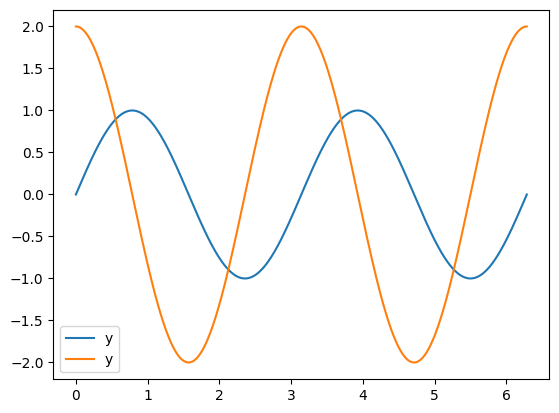

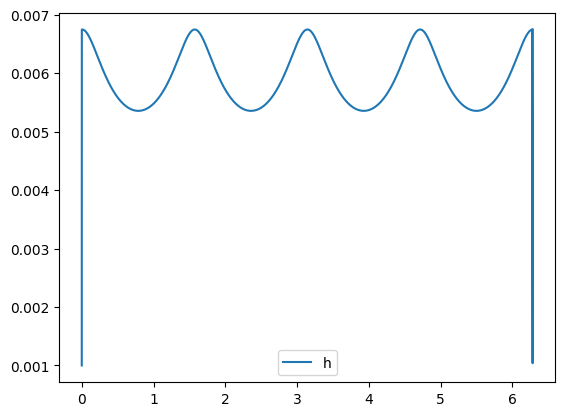

0.005867474594997992 1071


In [16]:
import matplotlib.pyplot as plt
import numpy as np
def IVP_solver(x_init: float, x_end: float, y_init: np.ndarray,
                h_0: float, tol: float, func, alpha: float):
    n = 0
    x_list = []
    y_list = []
    z_list = []
    h_list = []
    x_list.append(x_init)
    y_list.append(y_init)
    h_list.append(h_0)
    k_1 = func(x_list[0],y_list[0])
    while x_list[n]<x_end:
        h_list[n] = min(h_list[n], x_end-x_list[n])
        k_2 = func(x_list[n]+1/2*h_list[n], y_list[n] + 1/2*h_list[n]*k_1)
        k_3 = func(x_list[n] + 3/4*h_list[n], y_list[n] + 3/4*h_list[n]*k_2)
        y_list.append(np.array(y_list[n] + 1/9*h_list[n]*(2*k_1+3*k_2+4*k_3)))
        x_list.append(x_list[n] + h_list[n])
        k_4 = func(x_list[n+1],y_list[n+1])
        z_list.append(y_list[n] + 1/24*h_list[n]*(7*k_1 + 6*k_2 + 8*k_3 + 3*k_4))
        est = np.linalg.norm(y_list[n+1]-z_list[n])
        h_list.append(alpha * h_list[n] * (tol/est)**(1/3))
        if est < tol:
            n+=1
            k_1=k_4

    return np.array(x_list), np.array(y_list), np.array(z_list), np.array(h_list), n

def func_1(x,y):
    return  np.array([y[1], -4*np.sin(2*x)]) 

x_array, y_array, z_array, h_array, n = IVP_solver(0, 2*np.pi, np.array([0,2]), 10**(-3),
                                          10**(-7), func_1, 0.8)
plt.plot(x_array,y_array[:,0], label="y")
plt.plot(x_array,y_array[:,1], label="y")
plt.legend()
plt.show()
plt.plot(x_array,h_array, label = "h")
plt.legend()
plt.show()

print(np.average(h_array),n)
 

## Oppgave 1e)

In [22]:
def sekant_root(g,z_0,z_1, tol):
    z = [z_0, z_1]
    n=1
    while abs(z[n-1]-z[n])>tol:
        z.append((z[n-1]*g(z[n])-z[n]*g(z[n-1]))/(g(z[n])-g(z[n-1])))
        n+=1
    return z[n],n

def g(z):
    return z + np.sin(z) + np.cos(z)

print(sekant_root(g,-20,20,10**(-7)))

(np.float64(-0.45662470456763077), 7)
